In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score
from sklearn.ensemble import RandomForestClassifier
sns.set_style("whitegrid")

In [2]:
customer_df = pd.read_csv("cleaned_customer.csv")

print("Dataset Shape:", customer_df.shape)
customer_df.head()

Dataset Shape: (15431, 24)


,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,...,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,OrderFrequency,CustomerValue,InactivityScore,ComplaintRate,EngagementScore
0,0,13.0,1,1,26.0,2,1,3.0,3,0,...,20.0,4.0,11.0,1.0,203.22,0.785714,2235.42,0.071429,0.000000,33.0
1,0,5.0,0,3,11.0,4,1,2.0,3,2,...,14.0,2.0,5.0,3.0,165.24,0.833333,826.20,0.500000,0.000000,10.0
2,0,1.0,1,3,15.0,6,0,3.0,4,2,...,23.0,2.0,2.0,5.0,174.07,1.000000,348.14,2.500000,0.333333,6.0
3,0,1.0,1,1,19.0,6,1,4.0,4,4,...,14.0,2.0,2.0,5.0,151.47,1.000000,302.94,2.500000,0.000000,8.0
4,1,9.0,2,3,13.0,4,1,3.0,3,3,...,21.0,1.0,1.0,2.0,122.75,0.285714,122.75,0.470588,0.500000,3.0


In [3]:
# Create RFM dataframe
seg_df = customer_df.copy()

seg_df = seg_df[["DaySinceLastOrder",
                 "OrderCount",
                 "CashbackAmount"]]

# Rename properly
seg_df.rename(columns={
    "DaySinceLastOrder":"Recency",
    "OrderCount":"Frequency",
    "CashbackAmount":"Monetary"
}, inplace=True)

seg_df.head()

,Recency,Frequency,Monetary
0,1.0,11.0,203.22
1,3.0,5.0,165.24
2,5.0,2.0,174.07
3,5.0,2.0,151.47
4,2.0,1.0,122.75


In [4]:
seg_df["Recency"] = seg_df["Recency"].max() - seg_df["Recency"]

In [5]:

customer_df = customer_df.rename(
    columns={
        "DaySinceLastOrder": "Recency",
        "OrderCount": "Frequency",
        "CashbackAmount": "Monetary"
    }
)

print(customer_df.columns)

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'Frequency', 'Recency',
       'Monetary', 'OrderFrequency', 'CustomerValue', 'InactivityScore',
       'ComplaintRate', 'EngagementScore'],
      dtype='object')


In [6]:
print(seg_df.isnull().sum())

Recency      0
Frequency    0
Monetary     0
dtype: int64


In [7]:
num_cols = seg_df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = seg_df.select_dtypes(include=["object"]).columns

seg_df[num_cols] = seg_df[num_cols].fillna(seg_df[num_cols].median())
seg_df[cat_cols] = seg_df[cat_cols].fillna("Unknown")

le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    seg_df[col] = le.fit_transform(seg_df[col])
    le_dict[col] = le

scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_df[["Recency","Frequency","Monetary"]])

seg_scaled = seg_df[num_cols.tolist() + cat_cols.tolist()]

seg_scaled.head()

,Recency,Frequency,Monetary
0,45.0,11.0,203.22
1,43.0,5.0,165.24
2,41.0,2.0,174.07
3,41.0,2.0,151.47
4,44.0,1.0,122.75


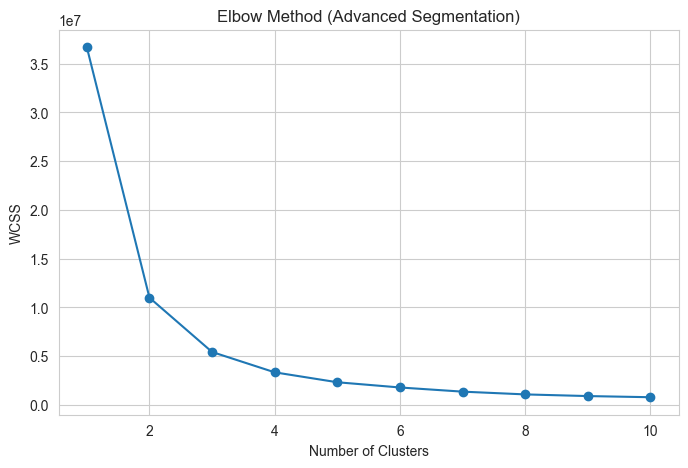

In [8]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(seg_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method (Advanced Segmentation)")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)
seg_df["Cluster"] = kmeans.fit_predict(seg_scaled)

customer_df["FinalCluster"] = seg_df["Cluster"]

customer_df.head()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,...,CouponUsed,Frequency,Recency,Monetary,OrderFrequency,CustomerValue,InactivityScore,ComplaintRate,EngagementScore,FinalCluster
0,0,13.0,1,1,26.0,2,1,3.0,3,0,...,4.0,11.0,1.0,203.22,0.785714,2235.42,0.071429,0.000000,33.0,3
1,0,5.0,0,3,11.0,4,1,2.0,3,2,...,2.0,5.0,3.0,165.24,0.833333,826.20,0.500000,0.000000,10.0,1
2,0,1.0,1,3,15.0,6,0,3.0,4,2,...,2.0,2.0,5.0,174.07,1.000000,348.14,2.500000,0.333333,6.0,1
3,0,1.0,1,1,19.0,6,1,4.0,4,4,...,2.0,2.0,5.0,151.47,1.000000,302.94,2.500000,0.000000,8.0,2
4,1,9.0,2,3,13.0,4,1,3.0,3,3,...,1.0,1.0,2.0,122.75,0.285714,122.75,0.470588,0.500000,3.0,2


In [10]:
features = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [11]:
cluster_summary = customer_df.groupby("FinalCluster")[features].mean()

print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
               Recency  Frequency    Monetary
FinalCluster                                 
0             6.906135   4.782822  287.109294
1             5.025737   2.986716  173.178093
2             3.244681   2.103536  138.907024
3             5.148549   3.902122  217.610546


In [12]:
churn_by_cluster = customer_df.groupby("FinalCluster")["Churn"].mean()

print("Churn Rate per Cluster:")
print(churn_by_cluster)

Churn Rate per Cluster:
FinalCluster
0    0.051534
1    0.121627
2    0.225502
3    0.156345
Name: Churn, dtype: float64


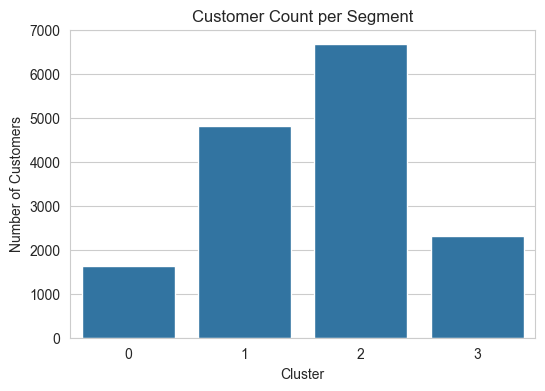

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="FinalCluster", data=customer_df)
plt.title("Customer Count per Segment")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

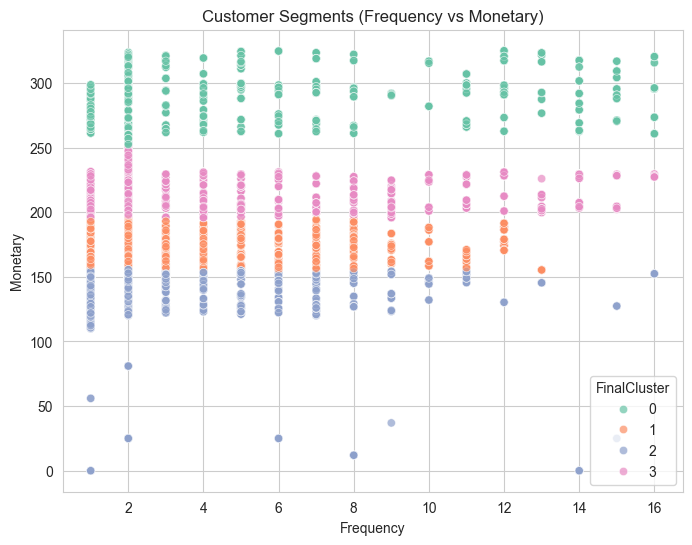

Frequency
1.0     4818
2.0     6266
3.0     1058
4.0      556
5.0      477
6.0      372
7.0      538
8.0      488
9.0      173
10.0      83
11.0     150
12.0     132
13.0      81
14.0     114
15.0      70
16.0      55
Name: count, dtype: int64

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer_df,
    x="Frequency",
    y="Monetary",
    hue="FinalCluster",
    palette="Set2",
    alpha=0.7
)

plt.title("Customer Segments (Frequency vs Monetary)")
plt.show()

customer_df["Frequency"].value_counts().sort_index()

In [15]:
seg_feature_cols = [
    "Recency",
    "Frequency",
    "Monetary"
]


joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "seg_scaler.pkl")
joblib.dump(seg_feature_cols,"seg_feature_columns.pkl")
print("Segmentation models saved successfully.")

Segmentation models saved successfully.


In [16]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

centroid_df = pd.DataFrame(
    centroids,
    columns=["Recency","Frequency","Monetary"]
)

print(centroid_df)

      Recency  Frequency      Monetary
0  182.095171  16.486311  14116.133826
1  188.856412  11.396014   8584.798337
2  195.260454   8.893015   6920.945300
3  188.414823  13.990342  10741.984435
